In [2]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
# Read CSV file from Lakehouse (Files section)
#df = spark.read.format("csv").option("header", "true").option("inferSchema", "true") \
#.load("abfss://MLOpsMLFlow@onelake.dfs.fabric.microsoft.com/MLDataLakehouse.Lakehouse/Files/diabetes.csv")

# Write as Delta table (managed table in Lakehouse)
#df.write.format("delta").mode("overwrite").saveAsTable("diabetes_table")

StatementMeta(, 4e9fa31b-a7b8-4c36-8a3a-31a15cd1fd71, 4, Finished, Available, Finished, False)

In [5]:
#df_test = spark.read.format("csv").option("header", "true").option("inferSchema", "true") \
#.load("abfss://MLOpsMLFlow@onelake.dfs.fabric.microsoft.com/MLDataLakehouse.Lakehouse/Files/diabetes-test.csv")

# Write as Delta table (managed table in Lakehouse)
# df_test.write.format("delta").mode("overwrite").saveAsTable("diabetes_test")

StatementMeta(, 4e9fa31b-a7b8-4c36-8a3a-31a15cd1fd71, 7, Finished, Available, Finished, False)

## Read the data from delta table from Lakehouse

In [1]:
df = spark.read.table("diabetes_table")
df_test = spark.read.table("diabetes_test")

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 3, Finished, Available, Finished, False)

In [2]:
df_test.head()

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 4, Finished, Available, Finished, False)

Row(Pregnancies=1, PlasmaGlucose=78, DiastolicBloodPressure=41, TricepsThickness=33, SerumInsulin=311, BMI=50.79639151, DiabetesPedigree=0.420803683, Age=24, Diabetic=0)

In [3]:
display(df)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 5, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 17fd2f1d-2367-46bb-940b-d57df4b51323)

In [4]:
df.schema

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 7, Finished, Available, Finished, False)

StructType([StructField('PatientID', IntegerType(), True), StructField('Pregnancies', IntegerType(), True), StructField('PlasmaGlucose', IntegerType(), True), StructField('DiastolicBloodPressure', IntegerType(), True), StructField('TricepsThickness', IntegerType(), True), StructField('SerumInsulin', IntegerType(), True), StructField('BMI', DoubleType(), True), StructField('DiabetesPedigree', DoubleType(), True), StructField('Age', IntegerType(), True), StructField('Diabetic', IntegerType(), True)])

In [5]:
df.show(10)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 8, Finished, Available, Finished, False)

+---------+-----------+-------------+----------------------+----------------+------------+-----------+----------------+---+--------+
|PatientID|Pregnancies|PlasmaGlucose|DiastolicBloodPressure|TricepsThickness|SerumInsulin|        BMI|DiabetesPedigree|Age|Diabetic|
+---------+-----------+-------------+----------------------+----------------+------------+-----------+----------------+---+--------+
|  1354778|          0|          171|                    80|              34|          23|43.50972593|     1.213191354| 21|       0|
|  1147438|          8|           92|                    93|              47|          36|21.24057571|     0.158364981| 23|       0|
|  1640031|          7|          115|                    47|              52|          35|41.51152348|     0.079018568| 23|       0|
|  1883350|          9|          103|                    78|              25|         304|29.58219193|     1.282869847| 43|       1|
|  1424119|          1|           85|                    59|         

## Convert to Pandas

In [6]:
import pandas as pd
df = df.toPandas()
df.head()


StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 11, Finished, Available, Finished, False)

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0


## Split Data

In [7]:
print("Splitting data...")
X, y = df[['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']].values, df['Diabetic'].values

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 13, Finished, Available, Finished, False)

Splitting data...


In [8]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 14, Finished, Available, Finished, False)

## Train Model

In [9]:
from sklearn.linear_model import LogisticRegression

print("Training model...")
model = LogisticRegression(C=1/0.1, solver="liblinear").fit(X_train, y_train)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 15, Finished, Available, Finished, False)

Training model...


## Evaluate Model

In [10]:
import numpy as np

y_hat = model.predict(X_test)
acc = np.average(y_hat == y_test)

print('Accuracy:', acc)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 16, Finished, Available, Finished, False)

Accuracy: 0.7736666666666666


In [11]:
import numpy as np

y_hat = model.predict(X_test)
acc = np.average(y_hat == y_test)

print('Accuracy:', acc)

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 17, Finished, Available, Finished, False)

Accuracy: 0.7736666666666666


In [13]:
from sklearn.metrics import roc_auc_score

y_scores = model.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])

print('AUC: ' + str(auc))

StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 19, Finished, Available, Finished, False)

AUC: 0.8483879795014677


StatementMeta(, 297e28c6-0e0d-4c97-b7e5-e8844d382902, 20, Finished, Available, Finished, False)

Text(0.5, 1.0, 'ROC Curve')

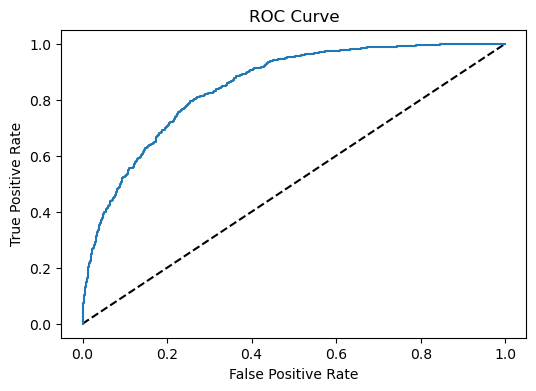

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])
fig = plt.figure(figsize=(6, 4))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')